In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv


Business problem:
Predict how much product will be sold in the future so the store keeps the right amount of inventory.

1. Stockout - Product finishes in the store → customers cannot buy.

2. Overstock - ';lToo much inventory → money gets stuck + storage cost.

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv')

# convert date
df['Date'] = pd.to_datetime(df['Date'])

# sort by time
df = df.sort_values('Date')

# fix inventory
df['Inventory Level'] = df['Inventory Level'].clip(lower=0)

# sales cannot exceed inventory
df['Units Sold'] = df[['Units Sold','Inventory Level']].min(axis=1)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
72,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,Snowy,0,18.90,Winter,0,110
71,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,Snowy,0,133.46,Winter,0,103
70,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,Snowy,0,62.29,Winter,0,61
69,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,Snowy,0,29.15,Winter,0,128


In [5]:
print(df.shape)
print(df.head() )
print(df.describe() )

(76000, 16)
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
72 2022-01-01     S004      P0013    Groceries   West              136   
71 2022-01-01     S004      P0012  Electronics   West              111   
70 2022-01-01     S004      P0011     Clothing   West              195   
69 2022-01-01     S004      P0010    Groceries   West              223   

    Units Sold  Units Ordered   Price  Discount Weather Condition  Promotion  \
0          102            252   72.72         5             Snowy          0   
72         104            385   20.24        10             Snowy          0   
71         111            113  118.15         0             Snowy          0   
70          60            293   52.89         0             Snowy          0   
69         120            597   30.02         0             Snowy          0   

    Competitor Pricing Seasonality  Epidemic  Demand  
0      

In [16]:
# Next Important Step (Very Important for Time Series)
# Before modeling we must check: Number of unique products, Number of stores, Date range, Missing dates
# This determines the forecasting strategy.

print(df.isnull().sum())
print(df.duplicated(subset=['Store ID','Product ID','Date']).sum())
how_old_data_is_available = df['Date'].min(), df['Date'].max()
print(how_old_data_is_available)

#rare category dataset 
print((df['Price'] < 0).sum())
print((df['Inventory Level'] < 0).sum())
print((df['Units Sold'] > df['Inventory Level']).sum())

# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated(subset=['Store ID','Product ID','Date']).sum())

# Date range
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Value checks
print("Negative price:", (df['Price'] < 0).sum())
print("Sales > Inventory:", (df['Units Sold'] > df['Inventory Level']).sum())

# How many products and stores exist
print("unique products: ", df['Product ID'].nunique())
print("unique stores: ", df['Store ID'].nunique())

# time gap between consecutive records
df['Date'].diff().value_counts()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64
0
(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-30 00:00:00'))
0
0
0
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64
Duplicates: 0
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Negative price: 0
Sales > Inventory: 0
unique products:  20


Date
0 days    75240
1 days      759
Name: count, dtype: int64

In [18]:
# understanding data 
# dataset size
print("Rows:", len(df))

# number of entities
print("Products:", df['Product ID'].nunique())
print("Stores:", df['Store ID'].nunique())
print("Regions:", df['Region'].nunique())

# date range
print("Date range:", df.index.min(), "to", df.index.max())

# missing values
print(df.isna().sum())

# duplicate rows
print("Duplicates:", df.reset_index().duplicated(subset=['Store ID','Product ID','Date']).sum())

# basic sanity checks
print("Negative price:", (df['Price'] < 0).sum())
print("Negative inventory:", (df['Inventory Level'] < 0).sum())

Rows: 76000
Products: 20
Stores: 5
Regions: 4
Date range: 0 to 75999
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64
Duplicates: 0
Negative price: 0
Negative inventory: 0


In [23]:
# checking if time-series data is valid before forecasting.

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Date range
print(df.index.min(), df.index.max())

# Future dates
print("Future dates:", (df.index > pd.Timestamp.today()).sum())

# Check records per day
print(df.groupby(df.index).size().describe())

2022-01-01 00:00:00 2024-01-30 00:00:00
Future dates: 0
count    760.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64


In [27]:
# lag features
df['lag_1'] = df.groupby(['Store ID','Product ID'])['Units Sold'].shift(1)
df['lag_7'] = df.groupby(['Store ID','Product ID'])['Units Sold'].shift(7)
df['lag_30'] = df.groupby(['Store ID','Product ID'])['Units Sold'].shift(30)

In [28]:
# rolling demand features
df['rolling_mean_7'] = (
    df.groupby(['Store ID','Product ID'])['Units Sold']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df['rolling_mean_30'] = (
    df.groupby(['Store ID','Product ID'])['Units Sold']
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [29]:
# calender features
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['week_of_year'] = df.index.isocalendar().week
df['day_of_month'] = df.index.day

In [31]:
# promotion features
df['promotion_flag'] = df['Promotion'].astype(int)

In [32]:
# price features
df['price_diff'] = df['Price'] - df['Competitor Pricing']
df['discount_effect'] = df['Price'] * df['Discount']

In [33]:
# weather features
df = pd.get_dummies(df, columns=['Weather Condition'], drop_first=True)

In [35]:
df = df.dropna()

In [37]:
target = 'Units Sold'

features = [col for col in df.columns if col != target]

# train test split
train = df.loc[:'2023-06-30']
test = df.loc['2023-07-01':]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [40]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [41]:
# training using XGBOOST
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
preds = model.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 13.98168659210205


In [44]:
print(df['Units Sold'].mean())

88.7119589041096


In [45]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 18.287308691540357


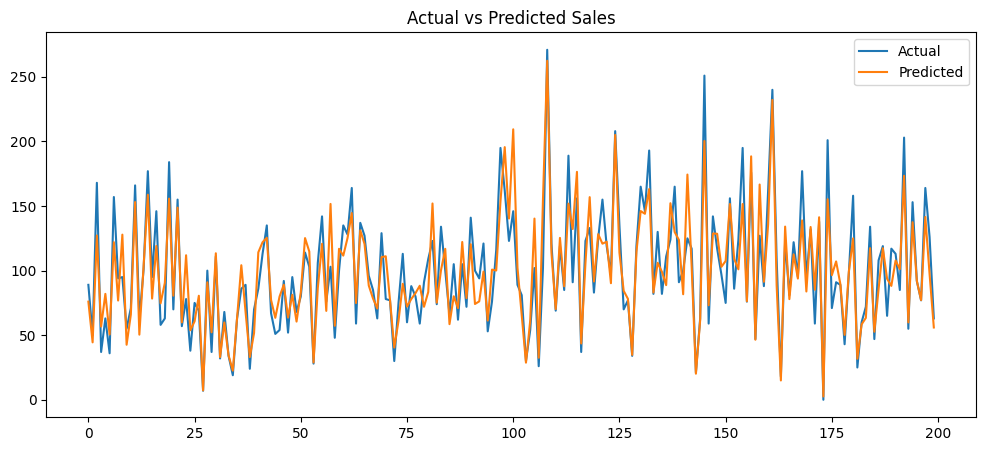

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(preds[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [47]:
# Number of days to forecast
future_days = 30

# Create future date range starting after last date in dataset
future_dates = pd.date_range(
    start=df.index.max() + pd.Timedelta(days=1),
    periods=future_days,
    freq='D'
)

# Create empty dataframe with these future dates
future_df = pd.DataFrame(index=future_dates)

# Copy last known feature values (simple assumption)
last_row = X_train.iloc[-1]

for col in X_train.columns:
    future_df[col] = last_row[col]

In [48]:
# Use trained XGBoost model to predict future sales
future_predictions = model.predict(future_df)

# Create forecast dataframe
forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Units_Sold": future_predictions
})

# View first few rows
print(forecast.head())

        Date  Forecasted_Units_Sold
0 2024-01-31             100.496666
1 2024-02-01             100.496666
2 2024-02-02             100.496666
3 2024-02-03             100.496666
4 2024-02-04             100.496666


In [49]:
# Save forecast to CSV file
forecast.to_csv("sales_forecast_next_30_days.csv", index=False)

print("Forecast file created successfully!")

Forecast file created successfully!
